# Customer Churn Prediction
## Notebook 7 of 8 — Model Improvement

This project predicts which telecom customers are likely to **churn** (cancel their service) so the business can reach them with retention offers *before* they leave. It walks through the full data-science lifecycle — exploration, cleaning, EDA, feature engineering, modelling, evaluation, and a tuned final model.

**Business problem:** Winning a new customer costs far more than keeping an existing one. This telecom loses roughly **27% of its customers**, and the leadership team wants a reliable, data-driven way to flag at-risk customers early enough to act.

**Tools & techniques:** Python · pandas · NumPy · Matplotlib · Seaborn · scikit-learn · XGBoost · SMOTE (imbalanced-learn) · joblib

> **This notebook:** we systematically push recall up — trying Random Forest and XGBoost, fixing the class imbalance with SMOTE, and tuning the decision threshold.

**Author:** La Yaung Linn Lett  &nbsp;·&nbsp;  **Last updated:** June 2026

---

## 1. Setup

**What:** Load the model-ready data and create the same train/test split used everywhere else.

**Why:** Using an identical split keeps every experiment comparable, so score differences come from the *model*, not the data.

In [1]:
# Standard library
import warnings

# Third-party
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
FIG_DIR = "../outputs/figures"

df = pd.read_csv("../data/processed/model_ready.csv")
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Data ready for experiments.")

C:\Users\Vivobook\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Data ready for experiments.


## 2. Random Forest

**What:** Train a default Random Forest.

**Why:** Random Forests capture non-linear interactions a linear baseline cannot. We check whether raw modelling power alone improves recall.

In [2]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf,
                            target_names=["Stayed", "Churned"]))

Accuracy: 0.791
              precision    recall  f1-score   support

      Stayed       0.83      0.91      0.86      1036
     Churned       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



**Insight:** A plain Random Forest actually has **worse recall (~0.47)** than the logistic baseline. A more powerful model does *not* fix the core problem — the model is still being trained on imbalanced data and learns to favour the majority "stayed" class.

## 3. Address the imbalance with SMOTE

**What:** Use SMOTE to synthetically balance the *training* classes, then retrain the Random Forest.

**Why:** SMOTE creates synthetic churner examples so the model sees a 50/50 split during training and stops ignoring the minority class. Crucially, we resample **only the training set** — the test set stays real and untouched.

In [3]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Confirm the training classes are now balanced
print("Balanced training distribution:")
print(y_train_sm.value_counts())

Balanced training distribution:
Churn
0    4138
1    4138
Name: count, dtype: int64


The training set is now perfectly balanced (**4,138 of each class**), while the test set remains real-world imbalanced for honest evaluation.

In [4]:
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_rf_sm = rf_smote.predict(X_test)

print(classification_report(y_test, y_pred_rf_sm,
                            target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.85      0.84      0.84      1036
     Churned       0.57      0.60      0.58       373

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.78      1409



**Insight:** SMOTE lifts Random Forest recall to **~0.60** — a clear improvement over the un-balanced version (~0.47). Balancing the training data matters more than the choice of algorithm.

## 4. XGBoost, with and without SMOTE

**What:** Train a gradient-boosted model (XGBoost) on the original and the SMOTE-balanced data.

**Why:** XGBoost is a top performer on tabular data. We test whether it, combined with SMOTE, gives us the best recall yet.

In [5]:
# XGBoost on the original (imbalanced) training data
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost (no SMOTE):")
print(classification_report(y_test, y_pred_xgb,
                            target_names=["Stayed", "Churned"]))

XGBoost (no SMOTE):
              precision    recall  f1-score   support

      Stayed       0.84      0.89      0.86      1036
     Churned       0.63      0.52      0.57       373

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [6]:
# XGBoost on the SMOTE-balanced training data
xgb_smote = XGBClassifier(n_estimators=100, random_state=42)
xgb_smote.fit(X_train_sm, y_train_sm)
y_pred_xgb_sm = xgb_smote.predict(X_test)
print("XGBoost + SMOTE:")
print(classification_report(y_test, y_pred_xgb_sm,
                            target_names=["Stayed", "Churned"]))

XGBoost + SMOTE:
              precision    recall  f1-score   support

      Stayed       0.86      0.83      0.85      1036
     Churned       0.58      0.62      0.60       373

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409



**Insight:** XGBoost + SMOTE reaches **~0.62 recall** at the default 0.5 threshold — the strongest model so far, and a solid foundation. But we are still short of the 70% recall target.

## 5. Tune the decision threshold

**What:** Instead of the default 0.5 cut-off, classify a customer as a churner when their predicted probability is **≥ 0.3**.

**Why:** The default threshold is arbitrary. Because missing a churner is far more costly than a false alarm, lowering the threshold makes the model more willing to flag at-risk customers — directly trading some precision for the recall the business cares about.

In [7]:
# Use predicted probabilities, then apply a lower 0.3 cut-off
y_pred_proba = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_pred_proba >= 0.3).astype(int)

print("XGBoost + SMOTE + threshold 0.3:")
print(classification_report(y_test, y_pred_thresh,
                            target_names=["Stayed", "Churned"]))

XGBoost + SMOTE + threshold 0.3:
              precision    recall  f1-score   support

      Stayed       0.89      0.71      0.79      1036
     Churned       0.48      0.75      0.59       373

    accuracy                           0.72      1409
   macro avg       0.68      0.73      0.69      1409
weighted avg       0.78      0.72      0.74      1409



**Insight:** Lowering the threshold to 0.3 pushes **recall to ~0.75** — the model now catches three out of four real churners and clears the 70% business target. Precision drops (more false alarms), but those are cheap: a needless retention offer costs far less than a lost customer.

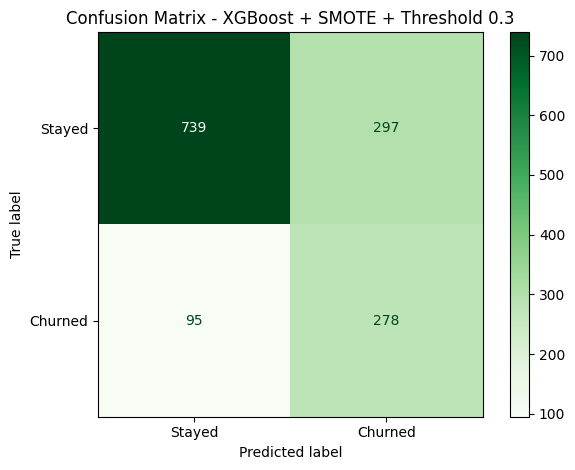

In [8]:
# Save the confusion matrix of the winning configuration
cm = confusion_matrix(y_test, y_pred_thresh)
disp = ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix - XGBoost + SMOTE + Threshold 0.3")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrix_final.png", dpi=150, bbox_inches="tight")
plt.show()

**Insight:** Compared with the baseline confusion matrix from Notebook 06, the bottom-left "missed churners" cell is now much smaller — exactly the improvement the business asked for.

## Section conclusion — how we lifted recall from 0.58 to 0.75

- A more powerful model alone (**Random Forest**) did *not* help — recall actually fell to ~0.47.
- **SMOTE** (balancing the training data) was the biggest single factor, lifting recall to ~0.60.
- **XGBoost + SMOTE** reached ~0.62 recall at the default threshold.
- **Lowering the decision threshold to 0.3** pushed recall to **~0.75**, meeting the ≥70% business target.

**Next:** Notebook 08 trains this winning configuration as the final model and saves it for reuse.